# Código de auxílio para o desenho do LGR

Código criado para a disciplina Projeto de Sistemas de Controle. Ele percorre os 10 passos para desenhar um LGR e os 2 passos para saber se um ponto pertence ao LGR.

Aviso, ele não te forneçe o gráfico final, apenas um esboço com as informações importantes para o desenho completo.

## Código de auxílio

In [2]:
# Bibliotecas utilizadas
import matplotlib.pyplot as plt
import sympy as sp
from sympy import symbols, I, Abs, re, im, Poly
from sympy.physics.control import *
import numpy as np
import matplotlib.pyplot as plt
import math
import cmath
from collections import Counter
import plotly.graph_objects as go

In [3]:
# Símbolos utilizados
s, k = sp.symbols('s k')

In [4]:
def polinomio(entrada):
    '''
    Função que transforma coeficientes em polinômios
    '''
    coeficientes = entrada.strip().split()  # Transforma a entrada em uma lista de strings e remove espaços extras
    coeficientes.reverse() # Inverte a lista
    lista_polinomio = []

    # Percorre de trás para frente para começar pelo maior expoente
    for exp in range(len(coeficientes) - 1, -1, -1):
        coef = coeficientes[exp]

        # Pula coeficientes que são zero
        if coef == "0":
            continue

        # Formata o termo dependendo do expoente
        if exp > 1:
            termo = f"{coef}*s**{exp}"
        elif exp == 1:
            termo = f"{coef}*s"
        else:
            termo = f"{coef}"

        lista_polinomio.append(termo)

    return " + ".join(lista_polinomio)


In [5]:
def lgr_eixo_real(polos, zeros, grande = -10):
    '''
    Função que retorna trechos reais lgr
    '''
    polos_reais = [polo for polo in polos if polo.imag == 0]
    zeros_reais = [zero for zero in zeros if zero.imag == 0]

    polos_zeros = polos_reais + zeros_reais
    polos_zeros.sort(reverse=True)
    i = 1
    linhas = []
    for ponto in polos_zeros:
        if(i % 2 == 1):
            inicio = ponto
        else:
            final = ponto
            linhas.append([inicio, final])
        i+=1
    if(i % 2 == 0): # Terminou com linha até o infinito
        linhas.append([inicio, grande])
    print("Segmentos do eixo real LGR:")
    for linha in linhas:
        print(linha)
    return linhas

In [6]:
def lugares_separados(polos, zeros):
    n_polos = len(polos)
    n_zeros = len(zeros)
    if(n_polos >= n_zeros):
        ls = n_polos
    else:
        ls = n_zeros
    print(f"O número de lugares separados é {ls}")
    return n_polos, n_zeros

In [7]:
def assintotas_zeros_infinitos(polos, zeros, n_polos, n_zeros):
    n_assintotas = n_polos - n_zeros

    # Cálculo de sigma
    soma_real = 0
    for polo in polos:
        parte_real = re(polo)
        soma_real += parte_real
    for zero in zeros:
        parte_real = re(zero)
        soma_real -= parte_real

    sigma = soma_real/(n_polos - n_zeros)

    #Cálculo do angulo das assintotas
    angulos_assintotas = []
    for q in range(n_polos - n_zeros): # 0, 1, 2, ..., (np - nz- 1)
        phi = (2*q + 1) *180/(n_polos - n_zeros)
        angulos_assintotas.append(phi)
    print(f"{n_assintotas} assintotas para zeros infinitos")
    print(f"As assintotas são centralizadas em {sigma:.2f}")
    print(f"As assintotas tem ângulo: {angulos_assintotas}")
    return sigma, angulos_assintotas

In [8]:
def plot_assintotas(ax, ponto, angulos, comprimento=10):
    x0, y0 = ponto

    for angulo in angulos:
        theta = np.radians(angulo)

        x1 = x0 + comprimento * np.cos(theta)
        y1 = y0 + comprimento * np.sin(theta)

        ax.plot([x0, x1], [y0, y1], linestyle='--')

    ax.scatter(x0, y0, color='black', zorder=3, label = "sigma", marker='P')
    ax.legend()


In [9]:
def raizes_derivada(ft):
    # Inverso negativo: -1 / ft
    # Converte o objeto de controle em uma expressão matemática comum do SymPy
    ft_expressao = ft.to_expr()

    # Agora você pode usar o sp.cancel() e fazer operações com números normalmente
    ft_inverso_negativo = sp.cancel(-1 / ft_expressao)
    ft_inverso_negativo
    df = sp.diff(ft_inverso_negativo, s)

    raizes = sp.solve(df, s)
    raizes_numericas = [complex(r.evalf()) for r in raizes]
    print("Raízes das derivadas:")
    for raiz in raizes_numericas:
        print(raiz)
    return raizes_numericas


In [10]:
def calc_ponto_saida(raizes, linhas):
    ponto_saida = []

    for raiz in raizes:
        if abs(im(raiz)) < 1e-60: # Leva em consideração erros de aproximação
            for linha in linhas:
                if re(raiz) > linha[1] and re(raiz) < linha[0]:
                    ponto_saida.append(raiz)
    print(f"Ponto de saída:")
    for ponto in ponto_saida:
        print(f"{ponto:.2f}")
    return ponto_saida

In [11]:
def tabela_routh_lgr(G, H, k):
    s = G.var

    # Equação característica:
    # D_G(s)*D_H(s) + k*N_G(s)*N_H(s) = 0

    polinomio = sp.expand(
        G.den * H.den +
        k * G.num * H.num
    )

    pol = sp.Poly(polinomio, s)

    coef = pol.all_coeffs()

    n = len(coef) - 1
    colunas = (n + 2) // 2

    tabela = sp.zeros(n + 1, colunas)

    tabela[0, :len(coef[0::2])] = sp.Matrix([coef[0::2]])
    tabela[1, :len(coef[1::2])] = sp.Matrix([coef[1::2]])

    for i in range(2, n + 1):
        for j in range(colunas - 1):
            a = tabela[i - 2, 0]
            b = tabela[i - 2, j + 1]
            c = tabela[i - 1, 0]
            d = tabela[i - 1, j + 1]

            tabela[i, j] = sp.simplify((c*b - a*d) / c)

    return tabela

In [12]:
def k_criticos_positivos(R, k):
    primeira_coluna = [sp.factor(R[i, 0]) for i in range(R.rows)]

    k_criticos = []

    for elemento in primeira_coluna:

        solucoes = sp.solve(elemento, k)

        for sol in solucoes:

            # Verifica se a solução é real e positiva
            if sol.is_real and sol >= 0:
                if sol not in k_criticos:
                    k_criticos.append(sol)

    return k_criticos

In [13]:
def resolver_linha_s2(R, k_criticos, s, k):
    """
    Recebe:
        R            -> tabela de Routh
        k_criticos   -> lista de ganhos críticos
        s            -> símbolo da variável s
        k            -> símbolo do ganho

    Retorna:
        Polos encontrados ao resolver a linha s^2 para cada K crítico.
    """

    # Índice da linha s^2:
    # linha s^n -> índice 0
    # ...
    # linha s^2 -> índice n - 2
    n = R.rows - 1
    indice_s2 = n - 2

    # Verifica se existe linha s^2
    if indice_s2 < 0:
        raise ValueError("A tabela não possui uma linha s^2.")

    # Pega os elementos da linha s^2
    linha_s2 = list(R[indice_s2, :])

    # Remove zeros do final
    while linha_s2 and linha_s2[-1] == 0:
        linha_s2.pop()

    # Constrói o polinômio da linha s^2
    # Exemplo: [1, 3] -> s^2 + 3
    polinomio_s2 = sum(
        linha_s2[j] * s**(2 - 2*j)
        for j in range(len(linha_s2))
    )

    print("Linha s^2:")
    display(polinomio_s2)

    resultados = []

    for kc in k_criticos:

        # Substitui o ganho crítico
        polinomio_k = sp.factor(
            polinomio_s2.subs(k, kc)
        )

        # Resolve a equação da linha s^2
        polos = sp.solve(
            sp.Eq(polinomio_k, 0),
            s
        )

        resultados.append(polos)

        print(f"\nK crítico = {kc}")
        print("Equação:")
        display(sp.Eq(polinomio_k, 0))

        print("Polos:")
        for polo in polos:
            sp.pprint(complex(polo.evalf()))

    return resultados

In [14]:
def angulo(v):
    """Retorna o argumento de um número complexo em graus."""
    return float(sp.deg(sp.arg(v)))


In [15]:

def angulo_partida(polo, polos, zeros):
    """
    Calcula o ângulo de partida de um polo complexo.

    polo  : polo de onde o ramo parte
    polos : lista com todos os polos
    zeros : lista com todos os zeros

    Retorna o ângulo em graus, no intervalo [-180, 180).
    """

    # Soma dos ângulos dos outros polos
    soma_polos = 0

    for p in polos:
        if p != polo:
            soma_polos += angulo(polo - p)

    # Soma dos ângulos dos zeros
    soma_zeros = 0

    for z in zeros:
        soma_zeros += angulo(polo - z)

    # Condição de ângulo:
    # soma_zeros - (soma_polos + phi) = 180°
    phi = soma_zeros - soma_polos - 180

    # Normaliza para [0, 360)
    phi = phi % 360


    return phi


In [16]:
def angulo_chegada(zero, polos, zeros):
    """
    Calcula o ângulo de chegada em um zero complexo.

    zero  : zero onde o ramo chega
    polos : lista com todos os polos
    zeros : lista com todos os zeros

    Retorna o ângulo em graus, no intervalo [-180, 180).
    """

    # Soma dos ângulos dos polos
    soma_polos = 0

    for p in polos:
        soma_polos += angulo(zero - p)

    # Soma dos ângulos dos outros zeros
    soma_zeros = 0

    for z in zeros:
        if z != zero:
            soma_zeros += angulo(zero - z)

    # Condição de ângulo:
    # (phi + soma_zeros) - soma_polos = 180°
    phi = 180 + soma_polos - soma_zeros

    # Normaliza para [0, 360)
    phi = phi % 360

    return phi

In [17]:
def chegada_saida(polos, zeros):
    polos_complexos = [p for p in polos if sp.im(p) != 0]
    zeros_complexos = [z for z in zeros if sp.im(z) != 0]

    angulos = []

    for p in polos_complexos:
        angulo = angulo_partida(p, polos, zeros)
        angulos.append([p, angulo])
        print(
            f"Polo {p}: "
            f"ângulo de partida = {angulo:.2f}°"
        )

    for z in zeros_complexos:
        angulo = angulo_chegada(z, polos, zeros)
        angulos.append([z, angulo])
        print(
            f"Zero {z}: "
            f"ângulo de chegada = {angulo:.2f}°"
        )
    return angulos


In [18]:
def plotar_angulos_chegada_saida(polos, ax, angulos, tamanho=0.5):
    """
    Desenha pequenas setas indicando os ângulos de partida
    dos polos e de chegada nos zeros.

    angulos:
        lista no formato [[ponto, angulo], ...]
    """

    for ponto, angulo in angulos:

        # Ângulo em graus -> radianos
        theta = np.deg2rad(angulo)

        # Coordenadas do ponto
        x = float(sp.re(ponto))
        y = float(sp.im(ponto))

        # Vetor correspondente ao ângulo
        dx = tamanho * np.cos(theta)
        dy = tamanho * np.sin(theta)

        # Determina se é polo ou zero
        # Polo -> seta saindo
        # Zero -> seta chegando
        if ponto in polos:
            x_inicio = x
            y_inicio = y
            x_fim = x + dx
            y_fim = y + dy
            cor = 'salmon'

        else:
            # Zero: a seta termina no zero
            x_inicio = x - dx
            y_inicio = y - dy
            x_fim = x
            y_fim = y
            cor = 'cyan'

        ax.annotate(
            '',
            xy=(x_fim, y_fim),
            xytext=(x_inicio, y_inicio),
            arrowprops=dict(
                arrowstyle='->',
                color=cor,
                lw=1.8,
                mutation_scale=12
            ),
            zorder=5
        )


In [19]:
def agrupar_multiplicidade(pontos, casas=6):
    """
    Agrupa polos/zeros repetidos e retorna:
    [(valor_complexo, multiplicidade), ...]
    """
    pontos_arredondados = [
        complex(round(p.real, casas), round(p.imag, casas))
        for p in pontos
    ]

    contagem = Counter(pontos_arredondados)

    return list(contagem.items())


## Passos LGR

In [20]:
print("Forneça os coeficientes da função G(s)...")
numerador_G = polinomio(input("Digite os coeficientes do numerador: "))
denominador_G = polinomio(input("Digite os coeficientes do denominador: "))

numerador_G = sp.parse_expr(numerador_G, local_dict={'s': s})
denominador_G = sp.parse_expr(denominador_G, local_dict={'s': s})

G = TransferFunction(numerador_G, denominador_G, s)
G

Forneça os coeficientes da função G(s)...
Digite os coeficientes do numerador: 1 1
Digite os coeficientes do denominador: 1 13 0


TransferFunction(s + 1, s**2 + 13*s, s)

In [21]:
print("Forneça os coeficientes da função H(s)...")
numerador_H = polinomio(input("Digite os coeficientes do numerador: "))
denominador_H = polinomio(input("Digite os coeficientes do denominador: "))

numerador_H = sp.parse_expr(numerador_H, local_dict={'s': s})
denominador_H = sp.parse_expr(denominador_H, local_dict={'s': s})

H = TransferFunction(numerador_H, denominador_H, s)
H

Forneça os coeficientes da função H(s)...
Digite os coeficientes do numerador: 1
Digite os coeficientes do denominador: 1 0


TransferFunction(1, s, s)

In [22]:
ft = Series(G, H).doit()


### Passo 01 - Escrever polinômio característico

In [23]:
ft_expandida = sp.expand(ft.num) / sp.expand(ft.den)

polinomio_caracteristico = 1 + k * ft_expandida

display(sp.Eq(polinomio_caracteristico,0))

Eq(k*(s + 1)/(s**3 + 13*s**2) + 1, 0)

### Passo 02 - Fatorar polinômio

In [24]:
ft_fatorada = sp.factor(ft.to_expr(), extension=sp.I)

polinomio_caracteristico = 1 + k * ft_fatorada

display(sp.Eq(polinomio_caracteristico,0))

Eq(k*(s + 1)/(s**2*(s + 13)) + 1, 0)

### Passo 03 - Assinalar polos e zeros

In [25]:
zeros, polos = pole_zero_numerical_data(ft)
print(f"Polos: {polos}")
print(f"Zeros: {zeros}")

Polos: [-13.0, 0.0, 0.0]
Zeros: [-1.0]


### Passo 04

In [26]:
linhas = lgr_eixo_real(polos, zeros)


Segmentos do eixo real LGR:
[0.0, 0.0]
[-1.0, -13.0]


### Passo 05 - Número de lugares separados

In [27]:
n_polos, n_zeros = lugares_separados(polos, zeros)

O número de lugares separados é 3


### Passo 06 - LGR é simétrico em relação ao eixo real

### Passo 07 - Segmentos em direção a zeros infinitos

In [28]:
sigma, angulos_assintotas = assintotas_zeros_infinitos(polos, zeros, n_polos, n_zeros)

2 assintotas para zeros infinitos
As assintotas são centralizadas em -6.00
As assintotas tem ângulo: [90.0, 270.0]


### Passo 08 - Pontos de saídas

In [29]:
raizes = raizes_derivada(ft)
ponto_saida = calc_ponto_saida(raizes, linhas)

Raízes das derivadas:
0j
(-5.732050807568878+0j)
(-2.267949192431123+0j)
Ponto de saída:
-5.73+0.00j
-2.27+0.00j


### Passo 09

In [30]:
rh = tabela_routh_lgr(G, H, k)
rh

Matrix([
[      1, k],
[     13, k],
[12*k/13, 0],
[      k, 0]])

In [31]:
Kc = k_criticos_positivos(rh, k)
eixo_img = resolver_linha_s2(rh, Kc, s, k)

Linha s^2:


k + 13*s**2


K crítico = 0
Equação:


Eq(13*s**2, 0)

Polos:
0j


### Passo 10

In [32]:
angulos = chegada_saida(polos, zeros)
angulos

[]

## Esboço LGR

In [34]:
polos_mult = agrupar_multiplicidade(polos)
zeros_mult = agrupar_multiplicidade(zeros)


/tmp/ipykernel_2740/1811305731.py:97: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "b." (-> marker='.'). The keyword argument will take precedence.
  ax.plot(x, y, 'b.', markersize=5, label = "ponto de saída", marker = 's', color = 'limegreen')
/tmp/ipykernel_2740/1811305731.py:97: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b." (-> color='b'). The keyword argument will take precedence.
  ax.plot(x, y, 'b.', markersize=5, label = "ponto de saída", marker = 's', color = 'limegreen')


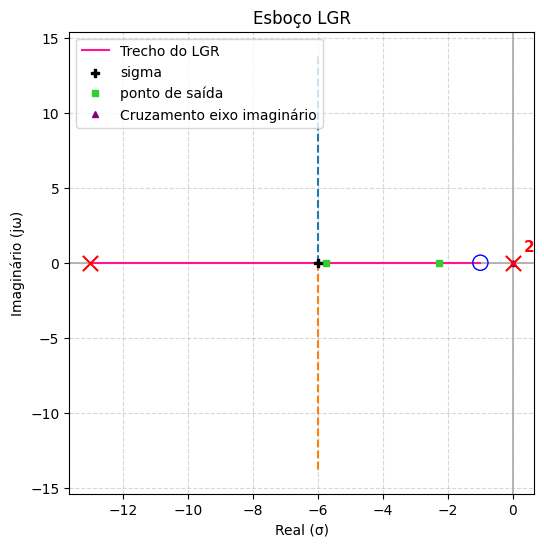

In [43]:
fig, ax = plt.subplots(figsize=(6, 6)) # Modificar limites

# ==========================
# POLOS
# ==========================

for polo, multiplicidade in polos_mult:

    ax.scatter(
        polo.real,
        polo.imag,
        marker='x',
        color='red',
        s=120,
        zorder=3
    )

    if multiplicidade > 1:
        ax.annotate(
            f'{multiplicidade}',
            (polo.real, polo.imag),
            xytext=(8, 8),
            textcoords='offset points',
            color='red',
            fontsize=11,
            fontweight='bold'
        )


# ==========================
# ZEROS
# ==========================

for zero, multiplicidade in zeros_mult:

    ax.scatter(
        zero.real,
        zero.imag,
        marker='o',
        color='blue',
        facecolors='none',
        s=120,
        zorder=3
    )

    if multiplicidade > 1:
        ax.annotate(
            f'{multiplicidade}',
            (zero.real, zero.imag),
            xytext=(8, 8),
            textcoords='offset points',
            color='blue',
            fontsize=11,
            fontweight='bold'
        )


ax.axhline(0, color='darkgray', linewidth=1.2) # Linha do Eixo Real
ax.axvline(0, color='darkgray', linewidth=1.2) # Linha do Eixo Imaginário

    # Configurações visuais finais do gráfico
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_xlabel('Real (σ)')
ax.set_ylabel('Imaginário (jω)')
ax.set_title(f'Esboço LGR')

primeira_linha = True
for linha in linhas:
        if primeira_linha:
            ax.plot([linha[0], linha[1]], [0, 0], color = 'deeppink', label='Trecho do LGR')
            primeira_linha = False
        else:
            ax.plot([linha[0], linha[1]], [0, 0], color = 'deeppink')

pontos = list(polos) + list(zeros)

x_vals = [p.real for p in pontos]
y_vals = [p.imag for p in pontos]

limite = max(
    max(abs(np.array(x_vals) - sigma)),
    max(abs(np.array(y_vals)))
)

comprimento = 2 * limite

plot_assintotas(
    ax,
    (sigma, 0),
    angulos_assintotas,
    comprimento
)

x = [r.real for r in ponto_saida]
y = [r.imag for r in ponto_saida]

ax.plot(x, y, 'b.', markersize=5, label = "ponto de saída", marker = 's', color = 'limegreen')

a = [sp.im(item) for sublist in eixo_img for item in sublist]

ax.plot(
    [0] * len(a), a,
    marker='^',
    linestyle='None',
    markersize=5,
    label="Cruzamento eixo imaginário",
    color='purple'
)

plotar_angulos_chegada_saida(polos, ax, angulos)

plt.legend()
plt.show()

## Teste de ponto

In [36]:
ponto_txt = input("Digite o ponto de teste (a+b*j): ")  # Digite: -3+4*j

ponto_si = sp.parse_expr(ponto_txt, local_dict={'j': sp.I})
print(ponto_si)

Digite o ponto de teste (a+b*j): 4 +2*j
4 + 2*I


### Passo 11 e 12

In [37]:
diferenca_polos = np.empty((0,2))
diferenca_zeros = np.empty((0,2))

print("Diferença entre o ponto e os polos: ")
for polo in polos:
  diferenca = ponto_si - polo
  modulo = abs(diferenca)
  fase = math.degrees(cmath.phase(diferenca))
  nova_linha = [[modulo.round(4), fase]]
  diferenca_polos = np.append(diferenca_polos, nova_linha, axis=0)
  print(f"{polo}: {nova_linha}")
print

print("Diferença entre o ponto e os zeros: ")
for zero in zeros:
    diferenca = ponto_si - zero
    modulo = abs(diferenca)
    fase = math.degrees(cmath.phase(diferenca))
    nova_linha = [[modulo.round(4), fase]]
    diferenca_zeros = np.append(diferenca_zeros, nova_linha, axis=0)
    print(f"{zeros}: {nova_linha}")


Diferença entre o ponto e os polos: 
-13.0: [[17.1172, 6.7098368077569335]]
0.0: [[4.4721, 26.56505117707799]]
0.0: [[4.4721, 26.56505117707799]]
Diferença entre o ponto e os zeros: 
[-1.0]: [[5.3852, 21.80140948635181]]


In [38]:
# Verifica se a função de transferência tem naturalmente um ganho
num = ft.num
den = ft.den

ganho = Poly(num, s).LC() / Poly(den, s).LC()
print(f"Ganho = {ganho}")

Ganho = 1


In [39]:
produto_polos = 1
produto_zeros = 1
theta = 0

for linha in diferenca_polos:
  produto_polos = produto_polos * linha[0]
  theta = theta - linha[1]

for linha in diferenca_zeros:
  produto_zeros = produto_zeros * linha[0]
  theta = theta + linha[1]

M = ganho * produto_zeros/produto_polos

# Tratamento para o angulo ser positivo
while theta < 0:
  theta += 360

In [40]:
# Testar se é LGR
while theta > 360:
  theta -= 360

if(theta > 175 and theta < 185):
    print("Fase certa")
    K = 1/M
    print(f"O K que gera esse polo é {K}")
else:
  print(f"Não é LGR, o angulo é {theta}")

Não é LGR, o angulo é 321.9614703244389


### Método extra - avaliando ponto na função de transferência

In [41]:
freq = ft.eval_frequency(ponto_si)
M = sp.Abs(freq)
theta = cmath.phase(freq) * 180/np.pi # a fase deve ser em graus
# Tratamento para o angulo ser positivo
while theta < 0:
  theta += 360

print(f"M = {M}. Theta = {theta}")

M = sqrt(8497)/5860. Theta = 321.9614703244389


In [42]:
# Testar se é LGR
while theta > 360:
  theta -= 360

if(theta > 175 and theta < 185): # 5 graus para erros de aproximação
  print("Fase certa!")
  K = 1/M
  print(f"O K que gera esse polo é {K}")
else:
  print("Não é LGR")

Não é LGR


## Gráfico geral

In [ ]:
def get_lgr_roots_for_k(k_val, G, H, s):
    """
    Calcula as raízes do polinômio característico para um dado valor de K.
    """
    # Polinômio característico: Den_G*Den_H + k*Num_G*Num_H = 0
    char_poly = sp.expand(G.den * H.den + k_val * G.num * H.num)
    # Resolve para s
    roots = sp.solve(char_poly, s)
    # Converte as raízes para números complexos e avalia numericamente
    return [complex(r.evalf()) for r in roots]

# Defina a faixa de valores de K para explorar
# Aumente 'num' para uma plotagem mais suave, 'stop' para explorar K maiores
k_values = np.linspace(0.001, 1000, 1000)

lgr_branches = []
for k_val in k_values:
    roots = get_lgr_roots_for_k(k_val, G, H, s)
    if roots:
        lgr_branches.append(roots)

# Transpõe a lista de raízes para ter cada ramo em uma sublista separada
# Isso é útil para plotar cada ramo contínuo
if lgr_branches:
    lgr_branches_T = list(map(list, zip(*lgr_branches)))
else:
    lgr_branches_T = []

print(f"Calculados {len(lgr_branches_T)} ramos do LGR para {len(k_values)} valores de K.")

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8)) # Modificar limites

# ==========================
# POLOS
# ==========================

for polo, multiplicidade in polos_mult:

    ax.scatter(
        polo.real,
        polo.imag,
        marker='x',
        color='red',
        s=120,
        zorder=3
    )

    if multiplicidade > 1:
        ax.annotate(
            f'{multiplicidade}',
            (polo.real, polo.imag),
            xytext=(8, 8),
            textcoords='offset points',
            color='red',
            fontsize=11,
            fontweight='bold'
        )


# ==========================
# ZEROS
# ==========================

for zero, multiplicidade in zeros_mult:

    ax.scatter(
        zero.real,
        zero.imag,
        marker='o',
        color='blue',
        facecolors='none',
        s=120,
        zorder=3
    )

    if multiplicidade > 1:
        ax.annotate(
            f'{multiplicidade}',
            (zero.real, zero.imag),
            xytext=(8, 8),
            textcoords='offset points',
            color='blue',
            fontsize=11,
            fontweight='bold'
        )


ax.axhline(0, color='darkgray', linewidth=1.2) # Linha do Eixo Real
ax.axvline(0, color='darkgray', linewidth=1.2) # Linha do Eixo Imaginário

    # Configurações visuais finais do gráfico
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_xlabel('Real (σ)')
ax.set_ylabel('Imaginário (jω)')
ax.set_title(f'Esboço LGR')

primeira_linha = True
for linha in linhas:
        if primeira_linha:
            ax.plot([linha[0], linha[1]], [0, 0], color = 'deeppink', label='Trecho do LGR')
            primeira_linha = False
        else:
            ax.plot([linha[0], linha[1]], [0, 0], color = 'deeppink')

pontos = list(polos) + list(zeros)

x_vals = [p.real for p in pontos]
y_vals = [p.imag for p in pontos]

# ==========================
# LGR Branches
# ==========================
if lgr_branches_T:
    for i, branch in enumerate(lgr_branches_T):
        real_parts = [r.real for r in branch]
        imag_parts = [r.imag for r in branch]
        ax.plot(real_parts, imag_parts, color='green', linewidth=0.8, alpha=0.7, label='LGR' if i == 0 else "")



limite = max(
    max(abs(np.array(x_vals) - sigma)),
    max(abs(np.array(y_vals)))
)

comprimento = 2 * limite

plot_assintotas(
    ax,
    (sigma, 0),
    angulos_assintotas,
    comprimento
)

x = [r.real for r in ponto_saida]
y = [r.imag for r in ponto_saida]

ax.plot(x, y, 'b.', markersize=5, label = "ponto de saída", marker = 's', color = 'limegreen')

a = [sp.im(item) for sublist in eixo_img for item in sublist]

ax.plot(
    [0] * len(a), a,
    marker='^',
    linestyle='None',
    markersize=5,
    label="Cruzamento eixo imaginário",
    color='purple'
)

plotar_angulos_chegada_saida(polos, ax, angulos)

ax.legend()
plt.show()